<a href="https://colab.research.google.com/github/yogitadhote06/Olist_Marketplace_Analysis/blob/main/Olist_Marketplace_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist E-Commerce Marketplace Performance & Customer Experience Analysis

**Role:** Data Analyst supporting Olist Operations and Customer Experience teams

### Business Objective
Determine how the marketplace performed over the available period, what factors are associated with customer satisfaction and dissatisfaction, where performance varies across sellers, geography, product categories and payment behavior, and what Olist should prioritize.

### Core Questions
1. How has Olist performed over time?
2. What factors are associated with customer satisfaction and dissatisfaction?
3. How strongly is delivery performance associated with customer reviews?
4. Where does performance vary most across sellers, geography and product categories?
5. What does payment behavior reveal about customers and satisfaction?
6. What operational priorities are supported by the evidence?

### Analytical principle
This notebook distinguishes **association from causation**. A relationship between two variables is evidence of association, not proof that one variable alone causes the other.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load the Olist datasets

The notebook first looks for the supplied Olist CSVs in `/content` (Google Colab) and `/mnt/data` (local execution). If files are not found, a Colab upload dialog is opened.

The code uses filename prefixes, so the notebook remains compatible with filenames such as `olist_orders_dataset(1).csv`.

In [2]:
# ============================================================
# 2. LOAD DATASETS
# ============================================================
required_prefixes = {
    "orders": "olist_orders_dataset",
    "items": "olist_order_items_dataset",
    "payments": "olist_order_payments_dataset",
    "reviews": "olist_order_reviews_dataset",
    "customers": "olist_customers_dataset",
    "sellers": "olist_sellers_dataset",
    "products": "olist_products_dataset",
    "geolocation": "olist_geolocation_dataset",
    "translation": "product_category_name_translation"
}

def find_file(prefix):
    search_dirs = ["/content", "/mnt/data", "."]
    matches = []
    for directory in search_dirs:
        matches.extend(glob.glob(os.path.join(directory, f"{prefix}*.csv")))
    # Prefer an exact base filename if available
    matches = sorted(set(matches), key=lambda x: ("(1)" in os.path.basename(x), len(x)))
    return matches[0] if matches else None

file_paths = {k: find_file(v) for k, v in required_prefixes.items()}
missing = [k for k, v in file_paths.items() if v is None]

if missing:
    try:
        from google.colab import files
        print("Missing files:", missing)
        print("Please select the Olist CSV files.")
        uploaded = files.upload()
        file_paths = {k: find_file(v) for k, v in required_prefixes.items()}
        missing = [k for k, v in file_paths.items() if v is None]
    except ImportError:
        pass

if missing:
    raise FileNotFoundError(
        "Missing required datasets: " + ", ".join(missing) +
        ". Upload all 9 Olist CSV files to Colab and rerun this cell."
    )

orders = pd.read_csv(file_paths["orders"])
items = pd.read_csv(file_paths["items"])
payments = pd.read_csv(file_paths["payments"])
reviews = pd.read_csv(file_paths["reviews"])
customers = pd.read_csv(file_paths["customers"])
sellers = pd.read_csv(file_paths["sellers"])
products = pd.read_csv(file_paths["products"])
geolocation = pd.read_csv(file_paths["geolocation"])
translation = pd.read_csv(file_paths["translation"])

datasets = {
    "Orders": orders,
    "Order Items": items,
    "Payments": payments,
    "Reviews": reviews,
    "Customers": customers,
    "Sellers": sellers,
    "Products": products,
    "Geolocation": geolocation,
    "Category Translation": translation
}

print("All required datasets loaded.")

Missing files: ['orders', 'items', 'payments', 'reviews', 'customers', 'sellers', 'products', 'geolocation', 'translation']
Please select the Olist CSV files.


Saving product_category_name_translation.csv to product_category_name_translation.csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset.csv
Saving olist_sellers_dataset.csv to olist_sellers_dataset.csv
Saving olist_products_dataset.csv to olist_products_dataset.csv
Saving olist_customers_dataset.csv to olist_customers_dataset.csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset.csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset.csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset.csv
Saving olist_orders_dataset.csv to olist_orders_dataset.csv
All required datasets loaded.


In [3]:
# ============================================================
# 3. DATASET INVENTORY
# ============================================================
inventory = pd.DataFrame({
    "Dataset": list(datasets.keys()),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

inventory

,Dataset,Rows,Columns
0,Orders,99441,8
1,Order Items,112650,6
2,Payments,103886,5
3,Reviews,100000,7
4,Customers,99441,5
5,Sellers,3095,4
6,Products,32951,9
7,Geolocation,1000163,5
8,Category Translation,71,2


In [4]:
# ============================================================
# 4. COLUMN OVERVIEW
# ============================================================
for name, df in datasets.items():
    print(f"\n{'='*70}\n{name.upper()}\n{'='*70}")
    display(pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "missing": [df[c].isna().sum() for c in df.columns],
        "unique": [df[c].nunique(dropna=True) for c in df.columns]
    }))


ORDERS


,column,dtype,missing,unique
0,order_id,object,0,99441
1,customer_id,object,0,99441
2,order_status,object,0,8
3,order_purchase_timestamp,object,0,98875
4,order_approved_at,object,160,90733
5,order_delivered_carrier_date,object,1783,81018
6,order_delivered_customer_date,object,2965,95664
7,order_estimated_delivery_date,object,0,459



ORDER ITEMS


,column,dtype,missing,unique
0,order_id,object,0,98666
1,order_item_id,int64,0,21
2,product_id,object,0,32951
3,seller_id,object,0,3095
4,price,float64,0,5968
5,freight_value,float64,0,6999



PAYMENTS


...

,column,dtype,missing,unique
0,product_id,object,0,32951
1,product_category_name,object,610,73
2,product_name_lenght,float64,610,66
3,product_description_lenght,float64,610,2960
4,product_photos_qty,float64,610,19
5,product_weight_g,float64,2,2204
6,product_length_cm,float64,2,99
7,product_height_cm,float64,2,102
8,product_width_cm,float64,2,95



GEOLOCATION


,column,dtype,missing,unique
0,geolocation_zip_code_prefix,int64,0,19015
1,geolocation_lat,float64,0,716685
2,geolocation_lng,float64,0,717097
3,geolocation_city,object,0,8011
4,geolocation_state,object,0,27



CATEGORY TRANSLATION


,column,dtype,missing,unique
0,product_category_name,object,0,71
1,product_category_name_english,object,0,71


## 3. Data Understanding

### Important table grains

- **Orders:** one row per order.
- **Order items:** one row per product line within an order.
- **Payments:** one row per payment installment/payment record; therefore an order can have multiple payment rows.
- **Reviews:** review records are linked to orders; duplicate review records for an order can occur.
- **Customers:** one row per customer-order combination, while `customer_unique_id` identifies the underlying customer.
- **Products:** one row per product.
- **Sellers:** one row per seller.
- **Geolocation:** multiple observations can exist for the same ZIP-code prefix.

Because these tables have different grains, joins must be designed carefully to avoid double counting.

In [5]:
# ============================================================
# 5. DUPLICATE AND KEY CHECKS
# ============================================================
key_checks = pd.DataFrame({
    "Table": ["Orders", "Items", "Payments", "Reviews", "Customers", "Sellers", "Products"],
    "Expected key": ["order_id", "order_id + order_item_id", "order_id + payment_sequential",
                     "review_id", "customer_id", "seller_id", "product_id"],
    "Duplicate rows": [
        orders.duplicated().sum(),
        items.duplicated().sum(),
        payments.duplicated().sum(),
        reviews.duplicated().sum(),
        customers.duplicated().sum(),
        sellers.duplicated().sum(),
        products.duplicated().sum()
    ]
})
key_checks

,Table,Expected key,Duplicate rows
0,Orders,order_id,0
1,Items,order_id + order_item_id,0
2,Payments,order_id + payment_sequential,0
3,Reviews,review_id,0
4,Customers,customer_id,0
5,Sellers,seller_id,0
6,Products,product_id,0


In [6]:
# ============================================================
# 6. DATE RANGE AND ORDER STATUS
# ============================================================
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for c in date_cols:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

print("Order purchase range:")
print(orders["order_purchase_timestamp"].min(), "to", orders["order_purchase_timestamp"].max())

print("\nOrder status distribution:")
display(orders["order_status"].value_counts().to_frame("orders"))

Order purchase range:
2016-09-04 21:15:19 to 2018-10-17 17:30:18

Order status distribution:


,orders
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [7]:
# ============================================================
# 7. DATA QUALITY SUMMARY
# ============================================================
quality = []
for name, df in datasets.items():
    quality.append({
        "Dataset": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "Missing cells": int(df.isna().sum().sum()),
        "Duplicate rows": int(df.duplicated().sum())
    })

quality_df = pd.DataFrame(quality)
quality_df

,Dataset,Rows,Columns,Missing cells,Duplicate rows
0,Orders,99441,8,4908,0
1,Order Items,112650,6,0,0
2,Payments,103886,5,0,0
3,Reviews,100000,7,146532,0
4,Customers,99441,5,0,0
5,Sellers,3095,4,0,0
6,Products,32951,9,2448,0
7,Geolocation,1000163,5,0,261836
8,Category Translation,71,2,0,0


## 4. Data Cleaning & Feature Engineering

We preserve missing delivery dates where they carry business meaning, rather than replacing them with arbitrary values.

For delivery analysis, only orders with a recorded customer-delivery date are treated as delivered. This prevents undelivered/cancelled orders from being incorrectly assigned a delivery duration.

In [8]:
# ============================================================
# 8. CLEAN ORDERS AND CREATE DELIVERY FEATURES
# ============================================================
orders_clean = orders.copy()

orders_clean["delivery_days"] = (
    orders_clean["order_delivered_customer_date"]
    - orders_clean["order_purchase_timestamp"]
).dt.total_seconds() / 86400

orders_clean["delay_days"] = (
    orders_clean["order_delivered_customer_date"]
    - orders_clean["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

orders_clean["late_delivery"] = np.where(
    orders_clean["order_delivered_customer_date"].notna(),
    orders_clean["delay_days"] > 0,
    np.nan
)

orders_clean["order_month"] = orders_clean["order_purchase_timestamp"].dt.to_period("M").astype(str)
orders_clean["order_year"] = orders_clean["order_purchase_timestamp"].dt.year
orders_clean["order_quarter"] = orders_clean["order_purchase_timestamp"].dt.to_period("Q").astype(str)

delivered = orders_clean[orders_clean["order_delivered_customer_date"].notna()].copy()

print(f"Total orders: {orders_clean['order_id'].nunique():,}")
print(f"Delivered orders with delivery date: {delivered['order_id'].nunique():,}")

Total orders: 99,441
Delivered orders with delivery date: 96,476


In [9]:
# ============================================================
# 9. CLEAN REVIEWS
# ============================================================
reviews_clean = reviews.copy()
reviews_clean["review_score"] = pd.to_numeric(reviews_clean["review_score"], errors="coerce")

# Use one review record per order for order-level satisfaction analysis.
# If multiple review records exist, take the mean score for that order.
review_order = (
    reviews_clean.groupby("order_id", as_index=False)
    .agg(review_score=("review_score", "mean"))
)

review_order["satisfaction_group"] = pd.cut(
    review_order["review_score"],
    bins=[0, 2, 3, 5],
    labels=["Dissatisfied (1-2)", "Neutral (3)", "Satisfied (4-5)"],
    include_lowest=True
)

review_order["dissatisfied_flag"] = (review_order["review_score"] <= 2).astype(int)
review_order["satisfied_flag"] = (review_order["review_score"] >= 4).astype(int)

display(review_order.head())

,order_id,review_score,satisfaction_group,dissatisfied_flag,satisfied_flag
0,00010242fe8c5a6d1ba2dd792cb16214,5.00,Satisfied (4-5),0,1
1,00018f77f2f0320c557190d7a144bdd3,4.00,Satisfied (4-5),0,1
2,000229ec398224ef6ca0657da4fc703e,5.00,Satisfied (4-5),0,1
3,00024acbcdf0a6daa1e931b038114c75,4.00,Satisfied (4-5),0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.00,Satisfied (4-5),0,1


In [10]:
# ============================================================
# 10. CLEAN CATEGORY DATA
# ============================================================
translation_clean = translation.drop_duplicates("product_category_name").copy()

products_clean = products.copy().merge(
    translation_clean,
    on="product_category_name",
    how="left"
)

products_clean["category"] = (
    products_clean["product_category_name_english"]
    .fillna(products_clean["product_category_name"])
    .fillna("Unknown")
)

products_clean["product_weight_g"] = pd.to_numeric(
    products_clean["product_weight_g"], errors="coerce"
)

products_clean["product_length_cm"] = pd.to_numeric(
    products_clean["product_length_cm"], errors="coerce"
)

products_clean["product_height_cm"] = pd.to_numeric(
    products_clean["product_height_cm"], errors="coerce"
)

products_clean["product_width_cm"] = pd.to_numeric(
    products_clean["product_width_cm"], errors="coerce"
)

print("Products after category enrichment:", len(products_clean))

Products after category enrichment: 32951


### Avoiding payment double counting

An order can contain multiple payment rows. Therefore, payment analysis first aggregates payment information to **one row per order** before joining it to the order-level analytical table.

In [11]:
# ============================================================
# 11. AGGREGATE PAYMENTS TO ORDER LEVEL
# ============================================================
payments_clean = payments.copy()

payments_clean["payment_value"] = pd.to_numeric(
    payments_clean["payment_value"], errors="coerce"
)
payments_clean["payment_installments"] = pd.to_numeric(
    payments_clean["payment_installments"], errors="coerce"
)

def dominant_payment_type(series):
    mode = series.mode()
    return mode.iloc[0] if len(mode) else "unknown"

payment_order = (
    payments_clean.groupby("order_id", as_index=False)
    .agg(
        payment_value=("payment_value", "sum"),
        max_installments=("payment_installments", "max"),
        payment_types=("payment_type", dominant_payment_type),
        payment_records=("payment_type", "size")
    )
)

payment_order.head()

,order_id,payment_value,max_installments,payment_types,payment_records
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card,1
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card,1
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card,1
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card,1


In [12]:
# ============================================================
# 12. BUILD ORDER-LEVEL ANALYTICAL TABLE
# ============================================================
order_analysis = (
    orders_clean
    .merge(
        customers[["customer_id", "customer_unique_id", "customer_state", "customer_city"]],
        on="customer_id",
        how="left"
    )
    .merge(review_order, on="order_id", how="left")
    .merge(payment_order, on="order_id", how="left")
)

# Create business-friendly labels
order_analysis["delivery_status"] = np.where(
    order_analysis["order_delivered_customer_date"].notna(),
    np.where(order_analysis["late_delivery"], "Late", "On Time / Early"),
    "Not Delivered"
)

order_analysis["delay_band"] = pd.cut(
    order_analysis["delay_days"],
    bins=[-np.inf, 0, 3, 7, 14, np.inf],
    labels=["On time / early", "1-3 days late", "4-7 days late",
            "8-14 days late", "15+ days late"]
)

print("Order-level analytical table shape:", order_analysis.shape)
display(order_analysis.head())

Order-level analytical table shape: (99441, 27)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,delay_days,late_delivery,order_month,order_year,order_quarter,customer_unique_id,customer_state,customer_city,review_score,satisfaction_group,dissatisfied_flag,satisfied_flag,payment_value,max_installments,payment_types,payment_records,delivery_status,delay_band
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.44,-7.11,0.00,2017-10,2017,2017Q4,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo,4.00,Satisfied (4-5),0,1,38.71,1.00,voucher,3.00,On Time / Early,On time / early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.78,-5.36,0.00,2018-07,2018,2018Q3,af07308b275d755c9edb36a90c618231,BA,barreiras,4.00,Satisfied (4-5),0,1,141.46,1.00,boleto,1.00,On Time / Early,On time / early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.39,-17.25,0.00,2018-08,2018,2018Q3,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis,5.00,Satisfied (4-5),0,1,179.12,3.00,credit_card,1.00,On Time / Early,On time / early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.21,-12.98,0.00,2017-11,2017,2017Q4,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante,5.00,Satisfied (4-5),0,1,72.20,1.00,credit_card,1.00,On Time / Early,On time / early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.87,-9.24,0.00,2018-02,2018,2018Q1,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre,5.00,Satisfied (4-5),0,1,28.62,1.00,credit_card,1.00,On Time / Early,On time / early


In [13]:
# ============================================================
# 13. BUILD ITEM-LEVEL ANALYTICAL TABLE
# ============================================================
item_analysis = (
    items
    .merge(
        products_clean[["product_id", "category", "product_weight_g",
                        "product_length_cm", "product_height_cm", "product_width_cm"]],
        on="product_id",
        how="left"
    )
    .merge(
        sellers[["seller_id", "seller_state", "seller_city"]],
        on="seller_id",
        how="left"
    )
)

item_analysis["price"] = pd.to_numeric(item_analysis["price"], errors="coerce")
item_analysis["freight_value"] = pd.to_numeric(item_analysis["freight_value"], errors="coerce")
item_analysis["freight_ratio"] = np.where(
    item_analysis["price"] > 0,
    item_analysis["freight_value"] / item_analysis["price"],
    np.nan
)

print("Item-level analytical table shape:", item_analysis.shape)
display(item_analysis.head())

Item-level analytical table shape: (112650, 14)


,order_id,order_item_id,product_id,seller_id,price,freight_value,category,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_state,seller_city,freight_ratio
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29,cool_stuff,650.00,28.00,9.00,14.00,SP,volta redonda,0.23
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,pet_shop,"30,000.00",50.00,30.00,40.00,SP,sao paulo,0.08
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87,furniture_decor,"3,050.00",33.00,13.00,33.00,MG,borda da mata,0.09
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,perfumery,200.00,16.00,10.00,15.00,SP,franca,0.98
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14,garden_tools,"3,750.00",35.00,40.00,30.00,PR,loanda,0.09


# 5. Exploratory Data Analysis — Marketplace Performance

We start with the marketplace-level KPIs, then examine trends over time.

In [14]:
# ============================================================
# 14. EXECUTIVE KPIs
# ============================================================
total_orders = orders_clean["order_id"].nunique()
unique_customers = customers["customer_unique_id"].nunique()
gmv = items["price"].sum()
freight_total = items["freight_value"].sum()
avg_review = review_order["review_score"].mean()

delivered_valid = delivered.copy()
late_rate = delivered_valid["late_delivery"].mean() * 100
avg_delivery = delivered_valid["delivery_days"].mean()
median_delivery = delivered_valid["delivery_days"].median()

cancel_rate = (orders_clean["order_status"].eq("canceled").mean()) * 100
satisfied_rate = (review_order["review_score"] >= 4).mean() * 100
dissatisfied_rate = (review_order["review_score"] <= 2).mean() * 100

kpis = pd.DataFrame({
    "Metric": [
        "Total orders", "Unique customers", "GMV / product revenue",
        "Freight value", "Average review score", "Satisfied reviews (4-5)",
        "Dissatisfied reviews (1-2)", "Average delivery days",
        "Median delivery days", "Late delivery rate", "Cancellation rate"
    ],
    "Value": [
        total_orders, unique_customers, gmv, freight_total, avg_review,
        satisfied_rate, dissatisfied_rate, avg_delivery, median_delivery,
        late_rate, cancel_rate
    ]
})

kpis

,Metric,Value
0,Total orders,"99,441.00"
1,Unique customers,"96,096.00"
2,GMV / product revenue,"13,591,643.70"
3,Freight value,"2,251,909.54"
4,Average review score,4.07
5,Satisfied reviews (4-5),76.60
6,Dissatisfied reviews (1-2),15.05
7,Average delivery days,12.56
8,Median delivery days,10.22
9,Late delivery rate,8.11


In [15]:
# ============================================================
# 15. MONTHLY MARKETPLACE TREND
# ============================================================
monthly_orders = (
    orders_clean.groupby("order_month", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("order_id", "size")
    )
)

# Revenue is calculated from item data, then aggregated by order month.
order_month_map = orders_clean[["order_id", "order_month"]].drop_duplicates()
monthly_revenue = (
    items.merge(order_month_map, on="order_id", how="left")
    .groupby("order_month", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "gmv"})
)

monthly_experience = (
    order_analysis[order_analysis["order_delivered_customer_date"].notna()]
    .groupby("order_month", as_index=False)
    .agg(
        avg_review=("review_score", "mean"),
        late_delivery_pct=("late_delivery", "mean")
    )
)

monthly = (
    monthly_revenue
    .merge(monthly_orders[["order_month", "orders"]], on="order_month", how="left")
    .merge(monthly_experience, on="order_month", how="left")
)

monthly["late_delivery_pct"] *= 100
monthly

,order_month,gmv,orders,avg_review,late_delivery_pct
0,2016-09,267.36,4,1.00,100.00
1,2016-10,"49,507.66",324,3.94,1.11
2,2016-12,10.90,1,5.00,0.00
3,2017-01,"120,312.87",800,4.18,3.07
4,2017-02,"247,303.02",1780,4.19,3.21
5,2017-03,"374,344.30",2682,4.17,5.58
6,2017-04,"359,927.23",2404,4.13,7.86
7,2017-05,"506,071.14",3700,4.22,3.61
8,2017-06,"433,038.60",3245,4.21,3.86
9,2017-07,"498,031.48",4026,4.25,3.43


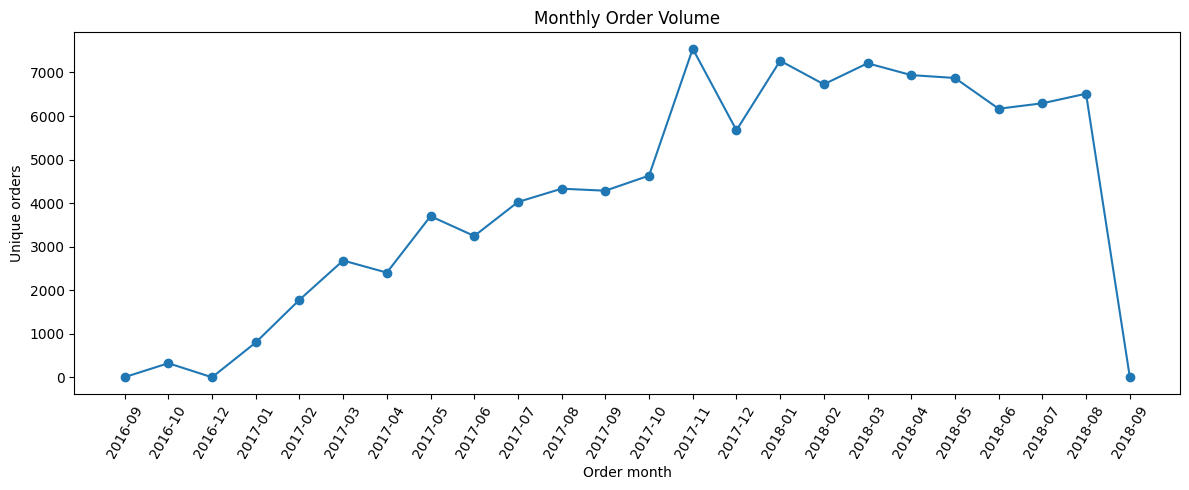

In [16]:
# ============================================================
# 16. VISUALIZATION: MONTHLY ORDERS
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(monthly["order_month"], monthly["orders"], marker="o")
plt.title("Monthly Order Volume")
plt.xlabel("Order month")
plt.ylabel("Unique orders")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

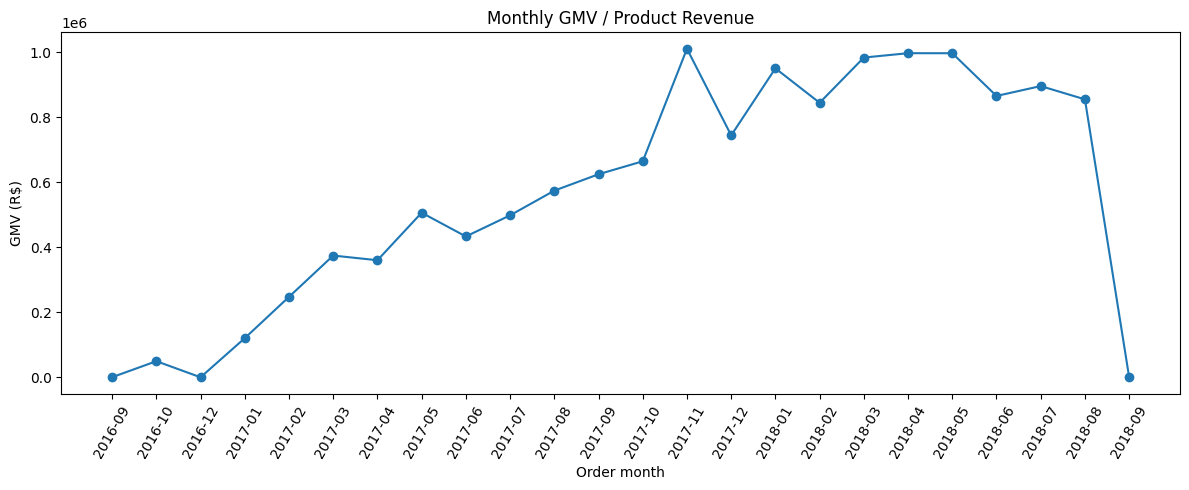

In [17]:
# ============================================================
# 17. VISUALIZATION: MONTHLY GMV
# ============================================================
plt.figure(figsize=(12, 5))
plt.plot(monthly["order_month"], monthly["gmv"], marker="o")
plt.title("Monthly GMV / Product Revenue")
plt.xlabel("Order month")
plt.ylabel("GMV (R$)")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

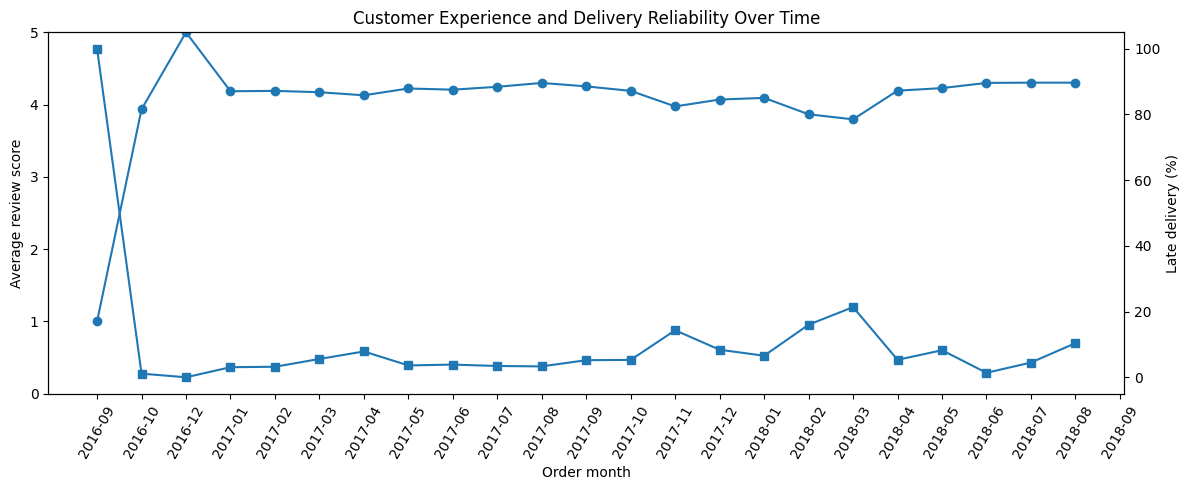

In [18]:
# ============================================================
# 18. VISUALIZATION: MONTHLY EXPERIENCE
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly["order_month"], monthly["avg_review"], marker="o", label="Average review")
ax1.set_ylabel("Average review score")
ax1.set_ylim(0, 5)

ax2 = ax1.twinx()
ax2.plot(monthly["order_month"], monthly["late_delivery_pct"], marker="s", label="Late delivery %")
ax2.set_ylabel("Late delivery (%)")

ax1.set_xlabel("Order month")
ax1.set_title("Customer Experience and Delivery Reliability Over Time")
ax1.tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

# 6. Customer Satisfaction Analysis

The key objective is to identify which observable marketplace conditions are associated with low review scores.

In [19]:
# ============================================================
# 19. REVIEW SCORE DISTRIBUTION
# ============================================================
review_dist = (
    reviews_clean["review_score"]
    .value_counts()
    .sort_index()
    .rename_axis("review_score")
    .reset_index(name="reviews")
)

review_dist["percentage"] = review_dist["reviews"] / review_dist["reviews"].sum() * 100
review_dist

,review_score,reviews,percentage
0,1,11858,11.86
1,2,3235,3.23
2,3,8287,8.29
3,4,19200,19.20
4,5,57420,57.42


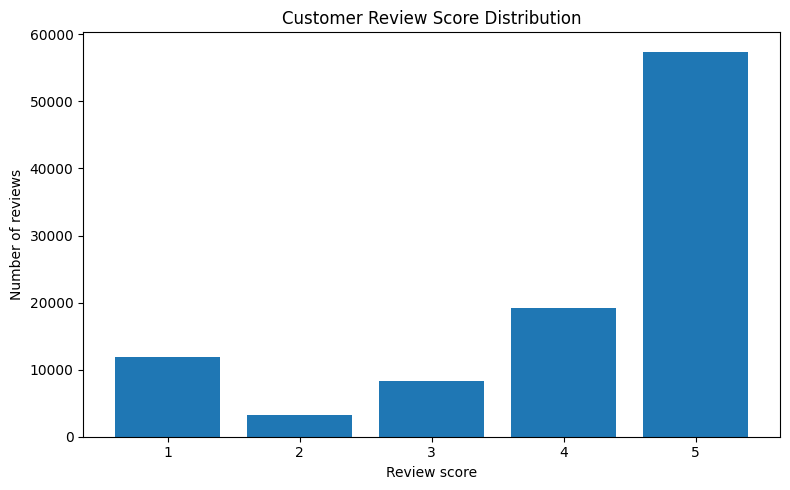

In [20]:
# ============================================================
# 20. VISUALIZATION: REVIEW DISTRIBUTION
# ============================================================
plt.figure(figsize=(8, 5))
plt.bar(review_dist["review_score"].astype(str), review_dist["reviews"])
plt.title("Customer Review Score Distribution")
plt.xlabel("Review score")
plt.ylabel("Number of reviews")
plt.tight_layout()
plt.show()

## Delivery performance vs customer satisfaction

This is a central business analysis. We compare review outcomes for orders delivered late versus on time/early, and then investigate whether dissatisfaction increases as delay becomes more severe.

In [21]:
# ============================================================
# 21. DELIVERY STATUS VS SATISFACTION
# ============================================================
delivery_review = (
    order_analysis[order_analysis["order_delivered_customer_date"].notna()]
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        dissatisfied_pct=("review_score", lambda x: (x <= 2).mean() * 100),
        satisfied_pct=("review_score", lambda x: (x >= 4).mean() * 100)
    )
    .reset_index()
)

delivery_review

,delivery_status,orders,avg_review,dissatisfied_pct,satisfied_pct
0,Late,7827,2.55,54.55,34.01
1,On Time / Early,88649,4.28,9.46,82.45


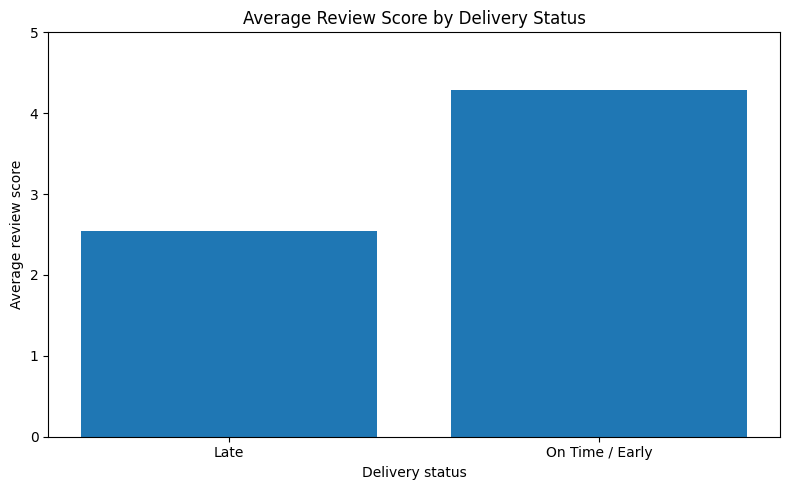

In [22]:
# ============================================================
# 22. VISUALIZATION: DELIVERY STATUS VS REVIEW
# ============================================================
plt.figure(figsize=(8, 5))
plt.bar(delivery_review["delivery_status"], delivery_review["avg_review"])
plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery status")
plt.ylabel("Average review score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# 23. DELAY SEVERITY ANALYSIS
# ============================================================
delay_analysis = (
    order_analysis[order_analysis["delay_band"].notna()]
    .groupby("delay_band", observed=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        dissatisfied_pct=("review_score", lambda x: (x <= 2).mean() * 100)
    )
    .reset_index()
)

delay_analysis

,delay_band,orders,avg_review,dissatisfied_pct
0,On time / early,88649,4.28,9.46
1,1-3 days late,2662,3.75,19.53
2,4-7 days late,1819,2.30,61.79
3,8-14 days late,1791,1.74,78.22
4,15+ days late,1555,1.71,78.78


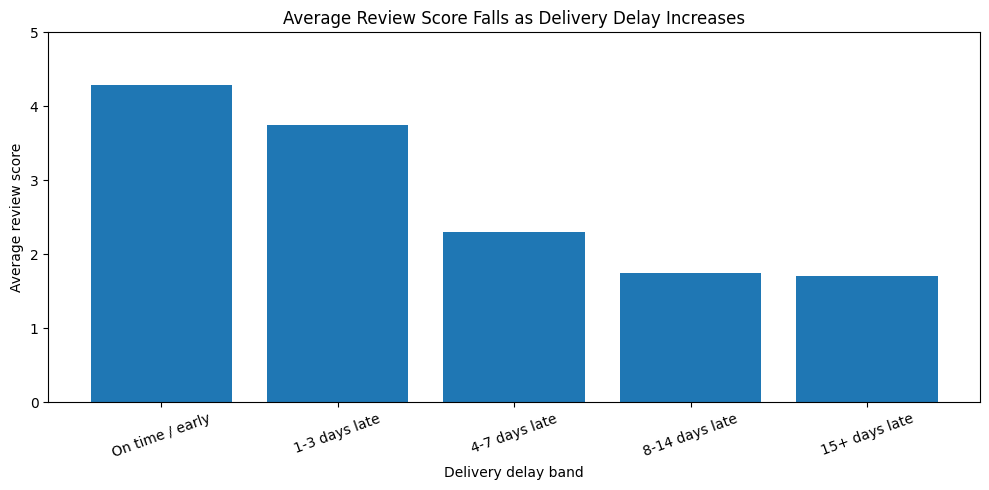

In [24]:
# ============================================================
# 24. VISUALIZATION: DELAY SEVERITY
# ============================================================
plt.figure(figsize=(10, 5))
plt.bar(delay_analysis["delay_band"].astype(str), delay_analysis["avg_review"])
plt.title("Average Review Score Falls as Delivery Delay Increases")
plt.xlabel("Delivery delay band")
plt.ylabel("Average review score")
plt.ylim(0, 5)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Interpretation

A strong negative association between delay severity and review score would indicate that delivery reliability is a major customer-experience priority. The analysis should be interpreted as association rather than causal proof.

In [25]:
# ============================================================
# 25. DELIVERY DELAY CORRELATION WITH REVIEW
# ============================================================
corr_df = order_analysis[
    ["review_score", "delay_days", "delivery_days", "payment_value"]
].dropna()

corr_matrix = corr_df.corr(numeric_only=True)
corr_matrix

,review_score,delay_days,delivery_days,payment_value
review_score,1.00,-0.27,-0.34,-0.04
delay_days,-0.27,1.00,0.61,-0.02
delivery_days,-0.34,0.61,1.00,0.07
payment_value,-0.04,-0.02,0.07,1.00


# 7. Product Category Analysis

In [26]:
# ============================================================
# 26. CATEGORY PERFORMANCE
# ============================================================
category_base = (
    item_analysis
    .merge(
        review_order[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
)

category_perf = (
    category_base.groupby("category", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        freight=("freight_value", "sum"),
        avg_review=("review_score", "mean"),
        dissatisfied_pct=("review_score", lambda x: (x <= 2).mean() * 100)
    )
)

category_perf["freight_ratio"] = category_perf["freight"] / category_perf["revenue"]
category_perf.sort_values("revenue", ascending=False).head(15)

,category,orders,revenue,freight,avg_review,dissatisfied_pct,freight_ratio
44,health_beauty,8836,"1,258,681.34","182,566.73",4.12,14.14,0.15
73,watches_gifts,5624,"1,205,005.68","100,535.93",4.00,16.68,0.08
8,bed_bath_table,9417,"1,036,988.68","204,693.04",3.87,19.37,0.20
68,sports_leisure,7720,"988,048.97","168,607.51",4.09,14.98,0.17
16,computers_accessories,6689,"911,954.32","147,318.08",3.92,18.76,0.16
40,furniture_decor,6449,"729,762.49","172,749.30",3.89,19.70,0.24
21,cool_stuff,3632,"635,290.85","84,039.10",4.13,13.49,0.13
50,housewares,5884,"632,248.66","146,149.11",4.04,16.04,0.23
6,auto,3897,"592,720.11","92,664.21",4.04,15.94,0.16
43,garden_tools,3518,"485,256.46","98,962.75",4.03,16.29,0.20


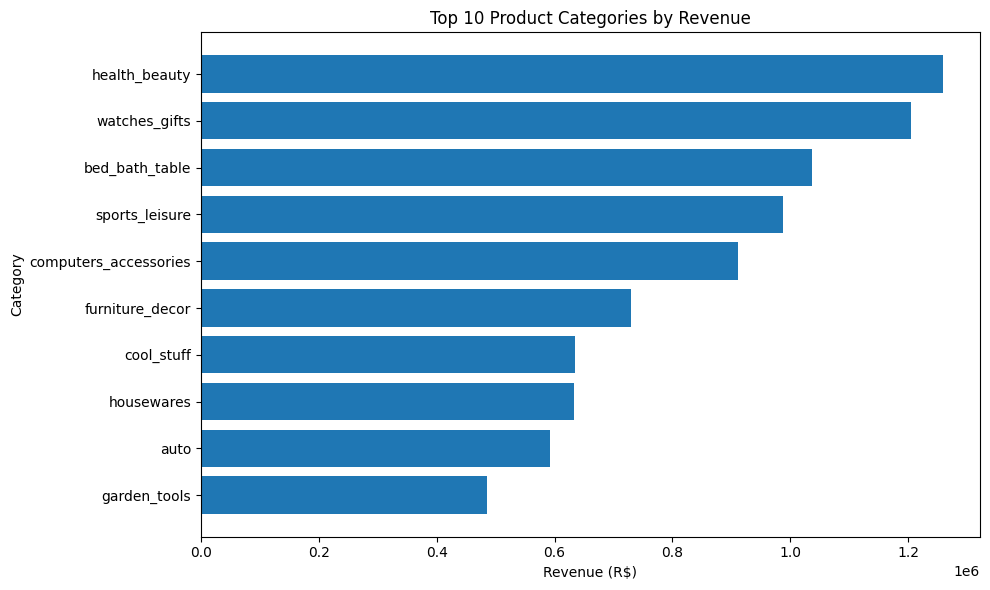

In [27]:
# ============================================================
# 27. TOP CATEGORIES BY REVENUE
# ============================================================
top_categories = category_perf.nlargest(10, "revenue").sort_values("revenue")

plt.figure(figsize=(10, 6))
plt.barh(top_categories["category"], top_categories["revenue"])
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue (R$)")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

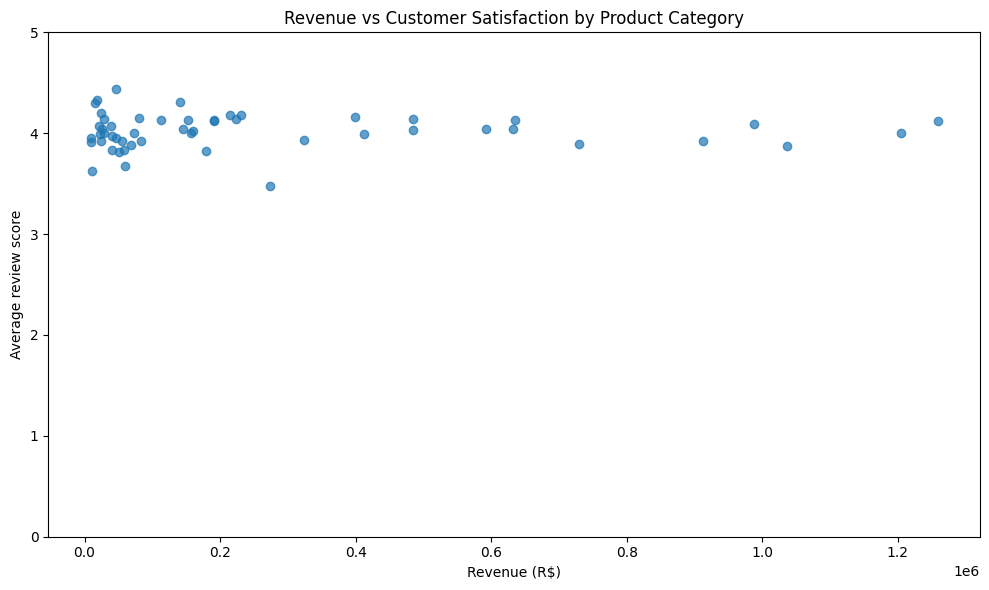

In [28]:
# ============================================================
# 28. CATEGORY REVENUE VS CUSTOMER SATISFACTION
# ============================================================
plot_cat = category_perf[category_perf["orders"] >= 100].copy()

plt.figure(figsize=(10, 6))
plt.scatter(plot_cat["revenue"], plot_cat["avg_review"], alpha=0.7)
plt.xlabel("Revenue (R$)")
plt.ylabel("Average review score")
plt.title("Revenue vs Customer Satisfaction by Product Category")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

# 8. Seller Performance Analysis

Seller performance is evaluated using both **volume and experience metrics**. A small seller with very few orders should not automatically outrank a high-volume seller based only on average rating.

In [29]:
# ============================================================
# 29. SELLER PERFORMANCE
# ============================================================
seller_base = (
    item_analysis
    .merge(
        review_order[["order_id", "review_score"]],
        on="order_id",
        how="left"
    )
    .merge(
        delivered[["order_id", "late_delivery", "delivery_days"]],
        on="order_id",
        how="left"
    )
)

seller_perf = (
    seller_base.groupby("seller_id", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        avg_review=("review_score", "mean"),
        dissatisfied_pct=("review_score", lambda x: (x <= 2).mean() * 100),
        late_delivery_pct=("late_delivery", "mean"),
        avg_delivery_days=("delivery_days", "mean")
    )
)

seller_perf["late_delivery_pct"] *= 100

# Minimum-volume threshold for stable comparison
seller_reliable = seller_perf[seller_perf["orders"] >= 50].copy()

print("Sellers with at least 50 orders:", len(seller_reliable))
display(seller_reliable.nlargest(10, "revenue"))

Sellers with at least 50 orders: 429


,seller_id,orders,revenue,avg_review,dissatisfied_pct,late_delivery_pct,avg_delivery_days
857,4869f7a5dfa277a7dca6462dcf3b52b2,1132,"229,472.63",4.11,14.01,11.59,15.01
1013,53243585a1d6dc2643021fd1853d8905,358,"222,776.05",4.07,12.68,4.00,13.37
881,4a3ca9315b744ce9f8e9374361493884,1806,"200,472.92",3.78,20.43,10.98,14.42
3024,fa1c13f2614d7b5c4749cbc52fecda94,585,"194,042.03",4.33,10.75,10.19,13.34
1535,7c67e1448b00f6e969d365cea6b010ab,982,"187,923.89",3.34,29.47,9.59,22.39
1560,7e93a43ef30c4f03f38b393420bc753a,336,"176,431.87",4.20,12.35,5.59,11.34
2643,da8622b14eb17ae2831f4ac5b9dab84a,1314,"160,236.57",4.06,15.22,7.30,11.17
1505,7a67c85e85bb2ce8582c35f2203ad736,1160,"141,745.53",4.22,11.36,5.89,11.17
192,1025f0e2d44d7041d6cf58b6550e0bfa,915,"138,968.55",3.84,20.52,9.23,12.05
1824,955fee9216a65b617aa5c0531780ce60,1287,"135,171.70",4.03,14.88,8.08,10.74


In [30]:
# ============================================================
# 30. HIGH-VOLUME SELLERS WITH HIGH DISSATISFACTION
# ============================================================
problem_sellers = (
    seller_reliable[
        (seller_reliable["orders"] >= 100) &
        (seller_reliable["dissatisfied_pct"].notna())
    ]
    .sort_values(["dissatisfied_pct", "orders"], ascending=[False, False])
)

problem_sellers.head(15)

,seller_id,orders,revenue,avg_review,dissatisfied_pct,late_delivery_pct,avg_delivery_days
333,1ca7077d890b907f89be8c954a02686a,115,"13,341.57",2.19,65.69,19.69,15.03
554,2eb70248d66e0e3ef83659f71b244378,202,"42,628.61",2.68,50.94,14.21,17.97
290,18a349e75d307f4b4cc646a691ed4216,121,"8,711.53",3.39,33.78,5.47,11.07
2139,b2479f944e1b90cf8a5de1bbfde284d6,103,"4,752.51",3.33,33.59,14.73,15.44
1669,88460e8ebdecbfecb5f9601833981930,248,"31,546.55",3.35,32.45,19.67,18.27
1385,710e3548e02bc1d2831dfc4f1b5b14d4,136,"23,979.11",3.38,32.39,4.38,14.31
1680,897060da8b9a21f655304d50fd935913,317,"23,023.92",3.37,32.33,12.11,14.86
2503,ce27a3cc3c8cc1ea79d11e561e9bebb6,135,"10,682.65",3.46,31.10,1.99,10.08
1535,7c67e1448b00f6e969d365cea6b010ab,982,"187,923.89",3.34,29.47,9.59,22.39
1371,7040e82f899a04d1b434b795a43b4617,212,"9,738.20",3.52,29.39,8.97,10.24


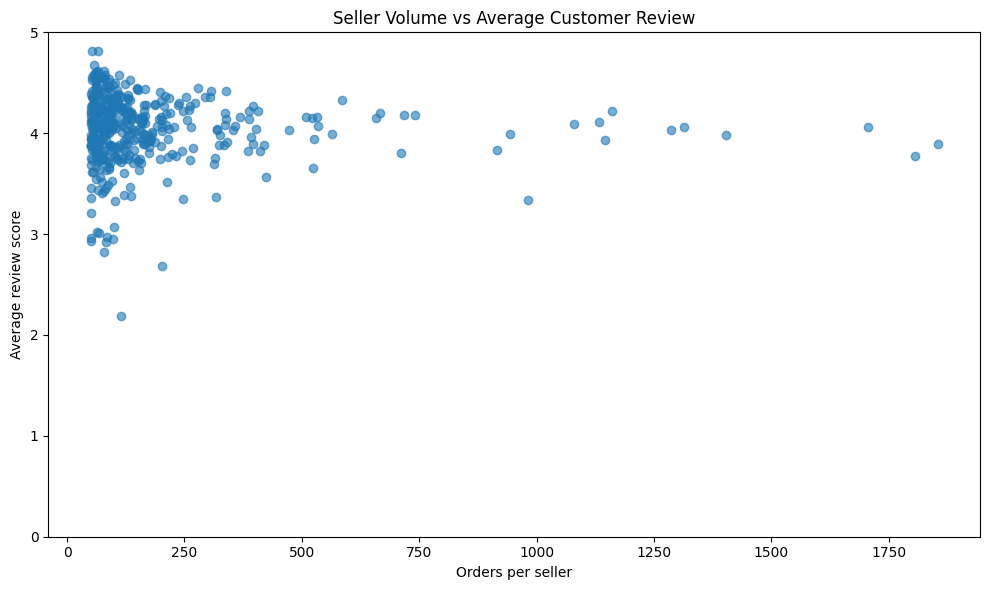

In [31]:
# ============================================================
# 31. SELLER VOLUME VS REVIEW
# ============================================================
seller_plot = seller_reliable.dropna(subset=["avg_review"])

plt.figure(figsize=(10, 6))
plt.scatter(seller_plot["orders"], seller_plot["avg_review"], alpha=0.6)
plt.xlabel("Orders per seller")
plt.ylabel("Average review score")
plt.title("Seller Volume vs Average Customer Review")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

# 9. Geographic Performance

We use customer state for customer-experience geography. This avoids making assumptions about the location of the customer based on city names alone.

In [32]:
# ============================================================
# 32. CUSTOMER STATE PERFORMANCE
# ============================================================
state_perf = (
    order_analysis[order_analysis["order_delivered_customer_date"].notna()]
    .groupby("customer_state", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        late_delivery_pct=("late_delivery", "mean"),
        avg_delivery_days=("delivery_days", "mean"),
        avg_payment_value=("payment_value", "mean")
    )
)

state_perf["late_delivery_pct"] *= 100
state_perf = state_perf.sort_values("orders", ascending=False)

state_perf

,customer_state,orders,avg_review,late_delivery_pct,avg_delivery_days,avg_payment_value
25,SP,40495,4.23,5.89,8.76,142.47
18,RJ,12353,3.95,13.47,15.31,166.45
10,MG,11355,4.18,5.62,12.01,160.22
22,RS,5344,4.18,7.15,15.30,161.23
17,PR,4923,4.23,5.00,11.99,158.83
23,SC,3547,4.12,9.75,14.96,167.85
4,BA,3256,3.91,14.04,19.34,181.59
6,DF,2080,4.13,7.07,12.97,166.42
7,ES,1995,4.05,12.23,15.79,159.24
8,GO,1957,4.09,8.18,15.61,170.82


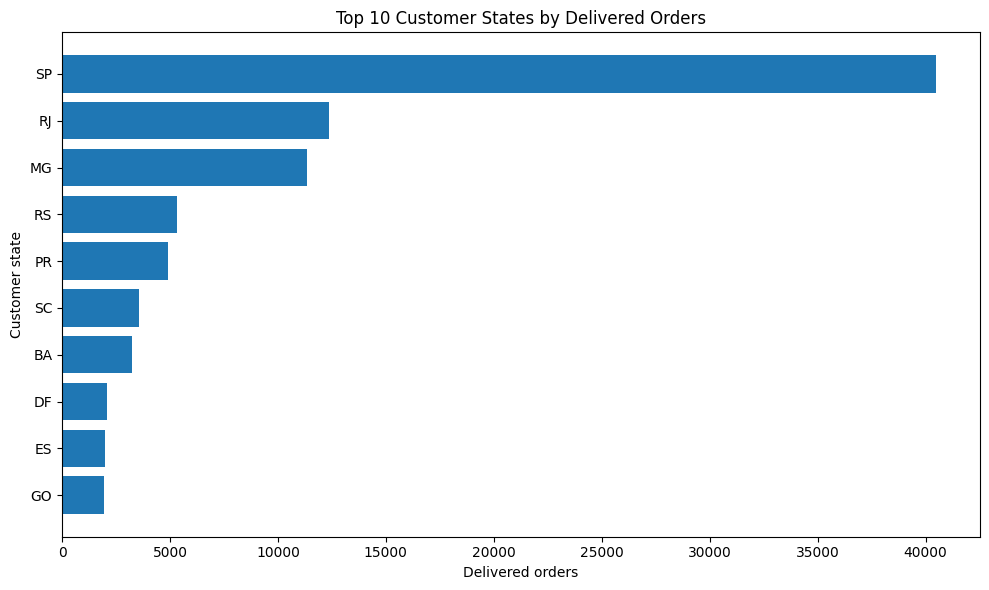

In [33]:
# ============================================================
# 33. VISUALIZATION: TOP STATES BY ORDERS
# ============================================================
top_states = state_perf.nlargest(10, "orders").sort_values("orders")

plt.figure(figsize=(10, 6))
plt.barh(top_states["customer_state"], top_states["orders"])
plt.title("Top 10 Customer States by Delivered Orders")
plt.xlabel("Delivered orders")
plt.ylabel("Customer state")
plt.tight_layout()
plt.show()

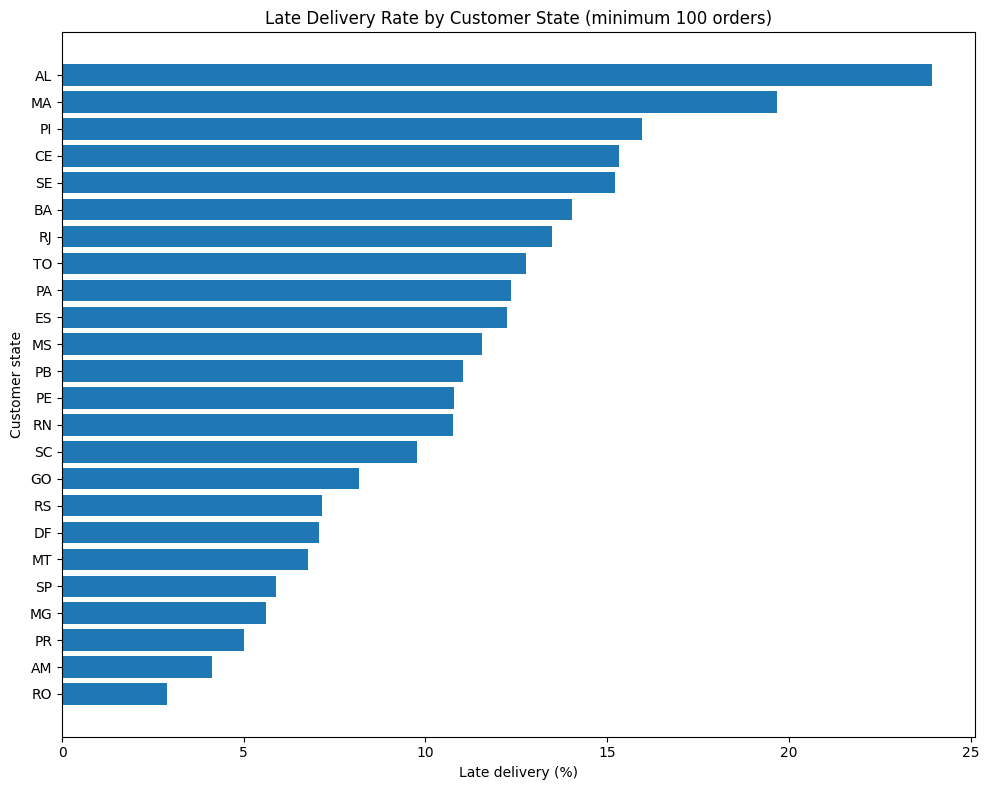

In [34]:
# ============================================================
# 34. VISUALIZATION: STATE DELIVERY PERFORMANCE
# ============================================================
state_plot = state_perf[state_perf["orders"] >= 100].sort_values("late_delivery_pct", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(state_plot["customer_state"], state_plot["late_delivery_pct"])
plt.title("Late Delivery Rate by Customer State (minimum 100 orders)")
plt.xlabel("Late delivery (%)")
plt.ylabel("Customer state")
plt.tight_layout()
plt.show()

# 10. Payment Behavior Analysis

In [35]:
# ============================================================
# 35. PAYMENT METHOD SUMMARY
# ============================================================
payment_summary = (
    payments_clean.groupby("payment_type", as_index=False)
    .agg(
        payment_records=("order_id", "size"),
        orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        avg_payment_record_value=("payment_value", "mean"),
        avg_installments=("payment_installments", "mean")
    )
    .sort_values("payment_value", ascending=False)
)

payment_summary

,payment_type,payment_records,orders,payment_value,avg_payment_record_value,avg_installments
1,credit_card,76795,76505,"12,542,084.19",163.32,3.51
0,boleto,19784,19784,"2,869,361.27",145.03,1.00
4,voucher,5775,3866,"379,436.87",65.70,1.00
2,debit_card,1529,1528,"217,989.79",142.57,1.00
3,not_defined,3,3,0.00,0.00,1.00


In [36]:
# ============================================================
# 36. PAYMENT METHOD VS SATISFACTION
# ============================================================
payment_experience = (
    order_analysis.dropna(subset=["payment_types"])
    .groupby("payment_types", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        avg_review=("review_score", "mean"),
        dissatisfied_pct=("review_score", lambda x: (x <= 2).mean() * 100),
        avg_payment_value=("payment_value", "mean"),
        avg_installments=("max_installments", "mean")
    )
    .sort_values("orders", ascending=False)
)

payment_experience

,payment_types,orders,avg_review,dissatisfied_pct,avg_payment_value,avg_installments
1,credit_card,76132,4.07,15.04,166.57,3.52
0,boleto,19784,4.07,14.81,145.03,1.00
4,voucher,1994,3.94,18.86,120.66,1.11
2,debit_card,1527,4.16,13.23,142.72,1.00
3,not_defined,3,1.67,66.67,0.00,1.00


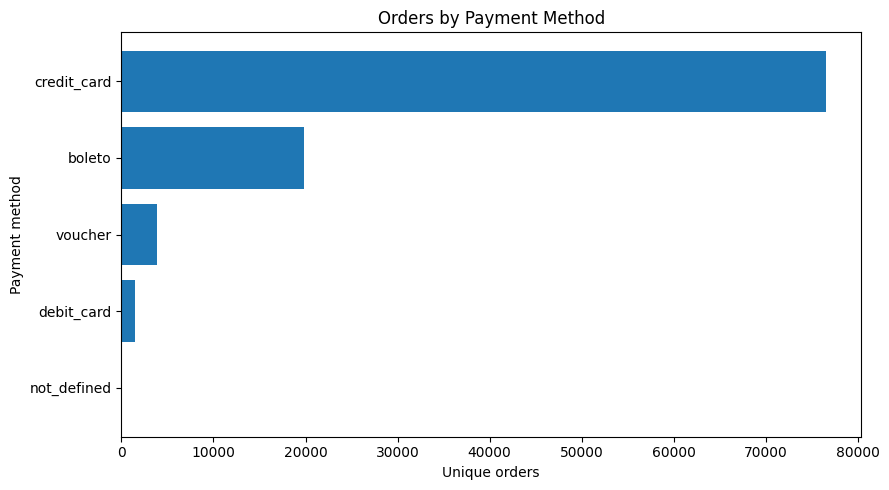

In [37]:
# ============================================================
# 37. VISUALIZATION: PAYMENT METHODS
# ============================================================
payment_plot = payment_summary.sort_values("orders")

plt.figure(figsize=(9, 5))
plt.barh(payment_plot["payment_type"], payment_plot["orders"])
plt.title("Orders by Payment Method")
plt.xlabel("Unique orders")
plt.ylabel("Payment method")
plt.tight_layout()
plt.show()

# 11. Optional Deep Dive — Freight Burden

Freight can represent a large share of the product price for lower-priced items. We investigate whether high freight burden is associated with customer dissatisfaction.

In [38]:
# ============================================================
# 38. FREIGHT BURDEN ANALYSIS
# ============================================================
freight_df = (
    item_analysis
    .merge(review_order[["order_id", "review_score"]], on="order_id", how="left")
)

freight_df["freight_ratio"] = freight_df["freight_ratio"].replace([np.inf, -np.inf], np.nan)

freight_df["freight_band"] = pd.cut(
    freight_df["freight_ratio"],
    bins=[-np.inf, 0.10, 0.20, 0.30, 0.50, np.inf],
    labels=["<=10%", "10-20%", "20-30%", "30-50%", ">50%"]
)

freight_analysis = (
    freight_df.groupby("freight_band", observed=False)
    .agg(
        item_rows=("order_id", "size"),
        avg_review=("review_score", "mean"),
        dissatisfied_pct=("review_score", lambda x: (x <= 2).mean() * 100)
    )
    .reset_index()
)

freight_analysis

,freight_band,item_rows,avg_review,dissatisfied_pct
0,<=10%,17510,4.05,16.44
1,10-20%,31340,4.05,15.70
2,20-30%,22615,4.05,15.46
3,30-50%,22244,3.97,17.43
4,>50%,18941,3.94,18.03


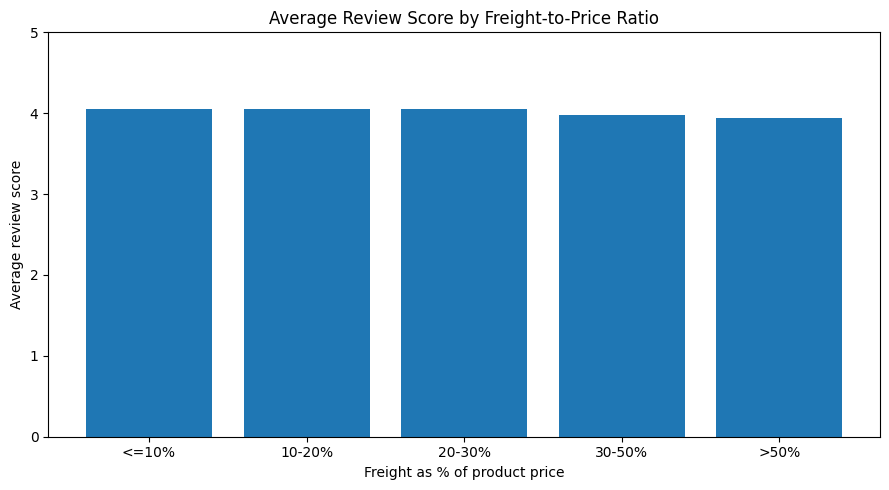

In [39]:
# ============================================================
# 39. VISUALIZATION: FREIGHT BURDEN
# ============================================================
plt.figure(figsize=(9, 5))
plt.bar(freight_analysis["freight_band"].astype(str), freight_analysis["avg_review"])
plt.title("Average Review Score by Freight-to-Price Ratio")
plt.xlabel("Freight as % of product price")
plt.ylabel("Average review score")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()

# 12. Optional Deep Dive — Delay Severity and Business Priority

The following table ranks delivery-delay bands by both customer-experience impact and order volume. This helps distinguish a severe problem that affects few orders from a moderate problem that affects many orders.

In [40]:
# ============================================================
# 40. PRIORITY MATRIX FOR DELIVERY
# ============================================================
delay_priority = delay_analysis.copy()
delay_priority["dissatisfied_orders_est"] = (
    delay_priority["orders"] * delay_priority["dissatisfied_pct"] / 100
)

delay_priority["order_share_pct"] = (
    delay_priority["orders"] / delay_priority["orders"].sum() * 100
)

delay_priority.sort_values("dissatisfied_orders_est", ascending=False)

,delay_band,orders,avg_review,dissatisfied_pct,dissatisfied_orders_est,order_share_pct
0,On time / early,88649,4.28,9.46,"8,388.00",91.89
3,8-14 days late,1791,1.74,78.22,"1,401.00",1.86
4,15+ days late,1555,1.71,78.78,"1,225.00",1.61
2,4-7 days late,1819,2.30,61.79,"1,124.00",1.89
1,1-3 days late,2662,3.75,19.53,520.00,2.76


# 13. Key Findings

The cells below calculate the headline findings directly from the analytical tables, so the narrative remains tied to the data.

In [41]:
# ============================================================
# 41. KEY FINDING CALCULATIONS
# ============================================================
on_time = delivery_review.loc[
    delivery_review["delivery_status"] == "On Time / Early"
].iloc[0]

late = delivery_review.loc[
    delivery_review["delivery_status"] == "Late"
].iloc[0]

review_gap = on_time["avg_review"] - late["avg_review"]
bad_rate_ratio = late["dissatisfied_pct"] / on_time["dissatisfied_pct"]

print(f"1. Overall average review score: {avg_review:.2f}/5.")
print(f"2. On-time/early orders average review: {on_time['avg_review']:.2f}; late orders: {late['avg_review']:.2f}.")
print(f"3. Review-score gap between on-time/early and late orders: {review_gap:.2f} points.")
print(f"4. 1-2 star rate: {on_time['dissatisfied_pct']:.1f}% for on-time/early vs {late['dissatisfied_pct']:.1f}% for late orders.")
print(f"5. Late orders have about {bad_rate_ratio:.1f}x the 1-2 star rate of on-time/early orders.")

1. Overall average review score: 4.07/5.
2. On-time/early orders average review: 4.28; late orders: 2.55.
3. Review-score gap between on-time/early and late orders: 1.74 points.
4. 1-2 star rate: 9.5% for on-time/early vs 54.6% for late orders.
5. Late orders have about 5.8x the 1-2 star rate of on-time/early orders.


In [42]:
# ============================================================
# 42. DELAY BAND FINDINGS
# ============================================================
for _, row in delay_analysis.iterrows():
    print(
        f"{row['delay_band']}: {int(row['orders']):,} orders, "
        f"average review {row['avg_review']:.2f}, "
        f"1-2 star rate {row['dissatisfied_pct']:.1f}%"
    )

On time / early: 88,649 orders, average review 4.28, 1-2 star rate 9.5%
1-3 days late: 2,662 orders, average review 3.75, 1-2 star rate 19.5%
4-7 days late: 1,819 orders, average review 2.30, 1-2 star rate 61.8%
8-14 days late: 1,791 orders, average review 1.74, 1-2 star rate 78.2%
15+ days late: 1,555 orders, average review 1.71, 1-2 star rate 78.8%


## Evidence-based interpretation

Based on the analysis, the final report should focus on:

1. **Marketplace growth and scale** — quantify the order and revenue trajectory rather than describing growth qualitatively.
2. **Delivery reliability** — late delivery is strongly associated with lower review scores, and the deterioration becomes especially severe as delays increase.
3. **Seller operations** — prioritize high-volume sellers with elevated dissatisfaction and late-delivery rates.
4. **Category management** — focus attention on high-revenue categories with weaker customer experience rather than only chasing the highest ratings.
5. **Geographic operations** — investigate states with high order volume and materially worse delivery reliability.
6. **Payment behavior** — payment method is primarily useful for understanding transaction mix and order-value behavior; differences in review scores should not be interpreted as causal without further controls.
7. **Freight burden** — investigate categories/products where freight represents a large share of item price.

### Important limitation
Review scores are customer-reported outcomes and may reflect factors beyond delivery. The analyses in this notebook establish associations and operational patterns; they do not by themselves establish causality.

# 14. Business Recommendations

### Priority 1 — Reduce severe delivery delays
Focus on orders that are **4+ days late**, particularly 8+ day delays, because the customer-experience deterioration is substantially larger in these groups.

### Priority 2 — Target high-volume problem sellers
Use the seller scorecard to identify sellers combining meaningful order volume with high dissatisfaction and late-delivery rates. These sellers can produce a larger absolute customer-impact opportunity than very small sellers.

### Priority 3 — Improve problematic geographic routes
Investigate states and seller-to-customer corridors with high order volume and elevated late-delivery rates. Operational changes should be prioritized where both customer impact and volume are high.

### Priority 4 — Protect high-revenue categories while fixing experience gaps
Categories with high revenue but below-average satisfaction deserve focused operational investigation because improvements can affect both customer experience and a meaningful portion of GMV.

### Priority 5 — Monitor freight burden
Where freight represents a large share of product price, review pricing/logistics arrangements and consider whether shipping economics are contributing to customer dissatisfaction.

### Priority 6 — Establish a recurring CX monitoring framework
Track a compact set of operational KPIs monthly:
- On-time delivery %
- 1–2 star review %
- Average review score
- 4+ day delay rate
- High-volume seller exception rate
- Category-level dissatisfaction
- State-level delivery reliability

This turns the analysis into an ongoing operational monitoring system rather than a one-time report.

# 15. Final Conclusion

The Olist marketplace shows substantial scale across the available period, with generally positive customer ratings. The strongest operational signal in the analysis is the relationship between **delivery reliability and customer satisfaction**: late orders receive materially lower ratings, and the effect becomes much more severe as the delay grows.

The next operational step should therefore be to move from broad averages to **targeted interventions** — identifying the sellers, states, categories and routes that account for the largest concentration of late and dissatisfied orders.

The accompanying Power BI tables provide a reproducible foundation for an executive dashboard.